# Problem Statement

#### Turn a static EV specification dataset into a reproducible machine-learning solution that predicts vehicle range from specifications and can be tested on new user inputs.

# 1. Importing Dependencies

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

import joblib

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

DATA_PATH = "../data/48c74e3c-91ff-4dda-ba7e-0939da12cf70.xls"   
TARGET = "range_km"
LEAKAGE_COLUMN = "efficiency_wh_per_km"   # never used as a model input as instructed in the problem statament


# 2. Data Audit

In [2]:
excel_file = pd.read_excel(DATA_PATH, sheet_name=0, engine="xlrd")
excel_file.to_csv("../data/raw.csv", index=False)

In [3]:
data = pd.read_csv('../data/raw.csv')
data.head()

,brand,model,top_speed_kmh,battery_capacity_kWh,battery_type,number_of_cells,torque_nm,efficiency_wh_per_km,range_km,acceleration_0_100_s,...,towing_capacity_kg,cargo_volume_l,seats,drivetrain,segment,length_mm,width_mm,height_mm,car_body_type,source_url
0,Abarth,500e Convertible,155,37.8,Lithium-ion,192.0,235.0,156,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1904/Abarth-500e-C...
1,Abarth,500e Hatchback,155,37.8,Lithium-ion,192.0,235.0,149,225,7.0,...,0.0,185,4,FWD,B - Compact,3673,1683,1518,Hatchback,https://ev-database.org/car/1903/Abarth-500e-H...
2,Abarth,600e Scorpionissima,200,50.8,Lithium-ion,102.0,345.0,158,280,5.9,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3057/Abarth-600e-S...
3,Abarth,600e Turismo,200,50.8,Lithium-ion,102.0,345.0,158,280,6.2,...,0.0,360,5,FWD,JB - Compact,4187,1779,1557,SUV,https://ev-database.org/car/3056/Abarth-600e-T...
4,Aiways,U5,150,60.0,Lithium-ion,NaN,310.0,156,315,7.5,...,NaN,496,5,FWD,JC - Medium,4680,1865,1700,SUV,https://ev-database.org/car/1678/Aiways-U5


In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 478 entries, 0 to 477
Data columns (total 22 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand                      478 non-null    str    
 1   model                      477 non-null    str    
 2   top_speed_kmh              478 non-null    int64  
 3   battery_capacity_kWh       478 non-null    float64
 4   battery_type               478 non-null    str    
 5   number_of_cells            276 non-null    float64
 6   torque_nm                  471 non-null    float64
 7   efficiency_wh_per_km       478 non-null    int64  
 8   range_km                   478 non-null    int64  
 9   acceleration_0_100_s       478 non-null    float64
 10  fast_charging_power_kw_dc  477 non-null    float64
 11  fast_charge_port           477 non-null    str    
 12  towing_capacity_kg         452 non-null    float64
 13  cargo_volume_l             477 non-null    str    
 14  seats

In [5]:
TARGET = 'range_km'

In [6]:
col_not_to_use_for_modeling = [TARGET, 'efficiency_wh_per_km']

In [7]:
num_col = data.select_dtypes(include=np.number).columns.drop(TARGET).tolist()
cat_col = data.select_dtypes(include= str).columns.tolist()

In [8]:
print(f"Numerical Columns : \n {num_col}\n\n\nCategorical COlumns : \n{cat_col}\n\n\n\n Target : {TARGET}")

Numerical Columns : 
 ['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'efficiency_wh_per_km', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm']


Categorical COlumns : 
['brand', 'model', 'battery_type', 'fast_charge_port', 'cargo_volume_l', 'drivetrain', 'segment', 'car_body_type', 'source_url']



 Target : range_km


#### Missing Value analysis

In [9]:

missing_summary = (
    data.isna().sum()
    .sort_values(ascending=False)
    .to_frame("missing_count")
)
missing_summary["missing_pct"] = (missing_summary["missing_count"] / len(data) * 100).round(1)
missing_summary[missing_summary["missing_count"] > 0]


,missing_count,missing_pct
number_of_cells,202,42.3
towing_capacity_kg,26,5.4
torque_nm,7,1.5
fast_charging_power_kw_dc,1,0.2
fast_charge_port,1,0.2
model,1,0.2
cargo_volume_l,1,0.2


#### Duplicate Value Analysis

In [10]:
print("Exact duplicate rows:", data.duplicated().sum())
print("Duplicate (brand, model) pairs:", data.duplicated(subset=["brand", "model"]).sum())


Exact duplicate rows: 0
Duplicate (brand, model) pairs: 0


#### Columns flagged in the problem statement as needing special handling

In [11]:

print("battery_type unique values:", data["battery_type"].unique())
print('\n'*3)

print("fast_charge_port value counts:\n", data["fast_charge_port"].value_counts())
print('\n'*3)

non_numeric_cargo = data[pd.to_numeric(data["cargo_volume_l"], errors="coerce").isna()
                            & data["cargo_volume_l"].notna()]
print("Non-numeric cargo_volume_l entries:")
non_numeric_cargo[["brand", "model", "cargo_volume_l"]]


battery_type unique values: <StringArray>
['Lithium-ion']
Length: 1, dtype: str




fast_charge_port value counts:
 fast_charge_port
CCS        476
CHAdeMO      1
Name: count, dtype: int64




Non-numeric cargo_volume_l entries:


,brand,model,cargo_volume_l
29,Audi,Q6 e-tron quattro,10 Banana Boxes
213,Maxus,MIFA 9,31 Banana Boxes
246,Mercedes-Benz,EQS SUV 580 4MATIC,13 Banana Boxes


Data Audit Takeawyss:
- battery_type is constant  → NO variance, no predictive value, drop.
- fast_charge_port is almost entirely CCS (476/478) → near-zero variance, drop.
- source_url is metadata, not a specification → drop.
- number_of_cells is missing in ~42% of rows — too much to safely impute as a trustworthy numeric value; we keep it as an **optional** engineered feature with a missingness flag rather than dropping it outright, per the problem statement's guidance.
- torque_nm (7 missing), fast_charging_power_kw_dc (1 missing), towing_capacity_kg (26 missing) are all low-missingness numeric columns → safe to impute.
- cargo_volume_l contains 3 entries recorded as **"N Banana Boxes"** instead of litres. We convert these using a documented assumption of **1 banana box = 52  litres** (as per wikipidiea) so the column becomes fully numeric without discarding real data.
- No exact duplicate rows.



# 3. Data Cleaning

Every transformation below is justified by the profiling step above.


In [12]:
df = data.copy()

before = len(df)
df = df.drop_duplicates()
print(f"Dropped {before - len(df)} exact duplicate rows")

BANANA_BOX_LITERS = 52  # documented assumption: 1 banana box = 52L

def clean_cargo_volume(value):
    if isinstance(value, str) and "Banana" in value:
        n_boxes = int(value.strip().split()[0])
        return n_boxes * BANANA_BOX_LITERS
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


df["model"] = df["model"].fillna("Unknown")

df["cells_missing_flag"] = df["number_of_cells"].isna().astype(int)

df = df.drop(columns=["battery_type", "fast_charge_port", "source_url"])

print(f"Shape after cleaning: {df.shape}")
df.isna().sum()[df.isna().sum() > 0]


Dropped 0 exact duplicate rows
Shape after cleaning: (478, 20)


number_of_cells              202
torque_nm                      7
fast_charging_power_kw_dc      1
towing_capacity_kg            26
cargo_volume_l                 1
dtype: int64

Remaining missing values (number_of_cells, torque_nm, fast_charging_power_kw_dc,
towing_capacity_kg) are handled by **median imputation inside the modelling pipeline**
, not here. Imputing before the train/test split would leak information about
the test set's distribution into training, so imputation is deliberately deferred into the
pipeline where it is fit on the training fold only.


# 4. Exploratory Data Analysis

EDA here is targeted at questions that affect modelling choices: what does the target look
like, which specifications move together, and do categorical variables separate range in a
way that's worth encoding carefully.


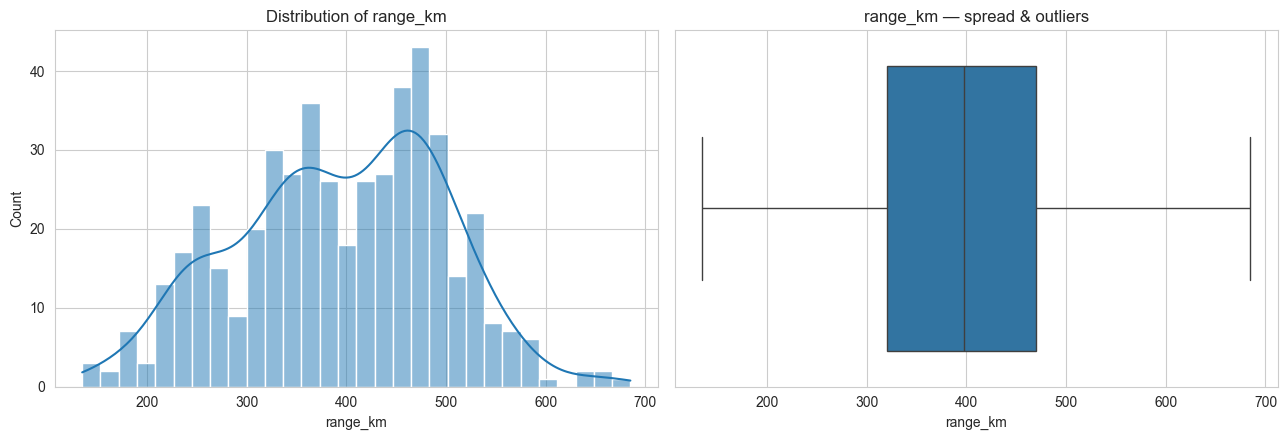

count    478.000000
mean     393.179916
std      103.287335
min      135.000000
25%      320.000000
50%      397.500000
75%      470.000000
max      685.000000
Name: range_km, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.histplot(df[TARGET], bins=30, kde=True, ax=axes[0])
axes[0].set_title("Distribution of range_km")
sns.boxplot(x=df[TARGET], ax=axes[1])
axes[1].set_title("range_km — spread & outliers")
plt.tight_layout()
plt.show()

print(df[TARGET].describe())


`range_km` is roughly unimodal and right-skewed with a long tail toward high-performance /
large-battery vehicles. There are no negative or clearly impossible values, so no outlier
removal is applied — extreme-but-real vehicles (e.g. large SUVs, performance EVs) are exactly
the cases the model needs to generalise to.


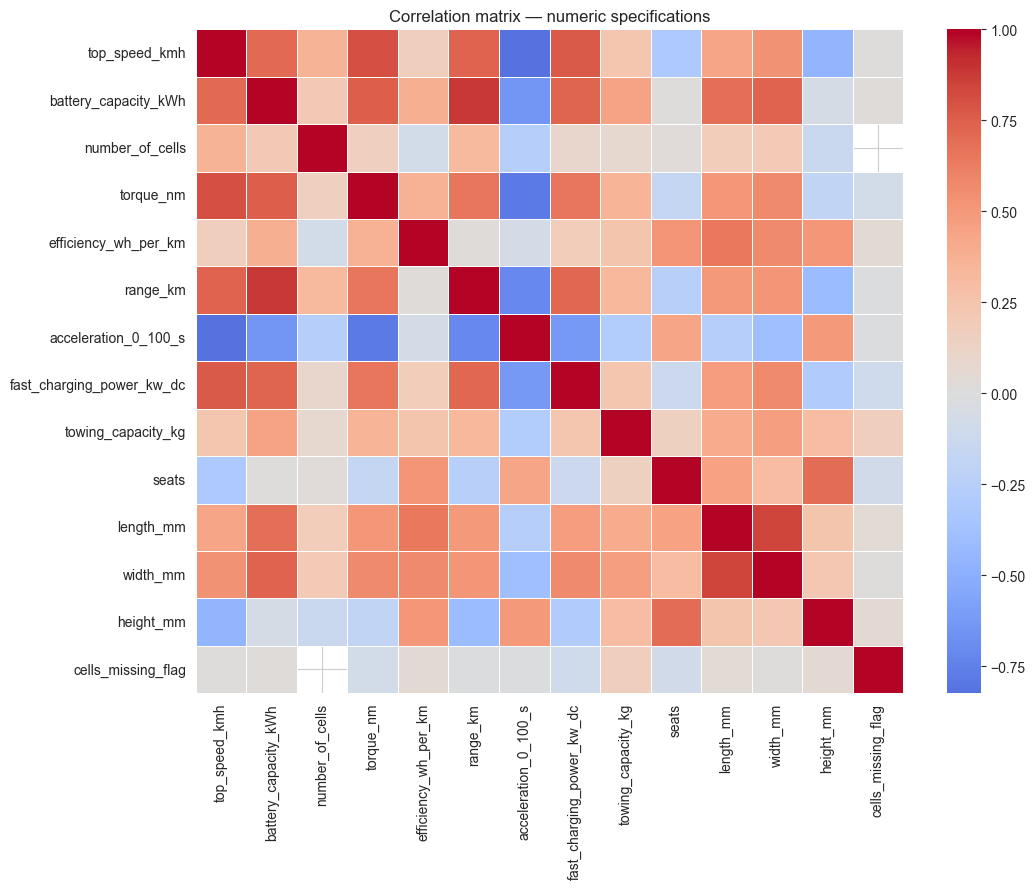

range_km                     1.000000
battery_capacity_kWh         0.880433
top_speed_kmh                0.732130
fast_charging_power_kw_dc    0.720932
torque_nm                    0.651651
width_mm                     0.521392
length_mm                    0.496867
towing_capacity_kg           0.333962
number_of_cells              0.311014
efficiency_wh_per_km         0.022943
cells_missing_flag          -0.013231
seats                       -0.248784
height_mm                   -0.413798
acceleration_0_100_s        -0.712486
Name: range_km, dtype: float64

In [14]:
numeric_cols_for_corr = df.select_dtypes(include=[np.number]).columns.tolist()
corr = df[numeric_cols_for_corr].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False, linewidths=0.4)
plt.title("Correlation matrix — numeric specifications")
plt.tight_layout()
plt.show()

corr[TARGET].sort_values(ascending=False)


`battery_capacity_kWh` is (as expected) the strongest single correlate of range.
`efficiency_wh_per_km` also correlates strongly with range — this *confirms* why it must be
excluded as a model input: range, battery capacity and efficiency are algebraically linked
(`range ≈ battery_capacity / efficiency × 1000`), so including efficiency would let the model
trivially reconstruct the target instead of learning from genuine specifications.


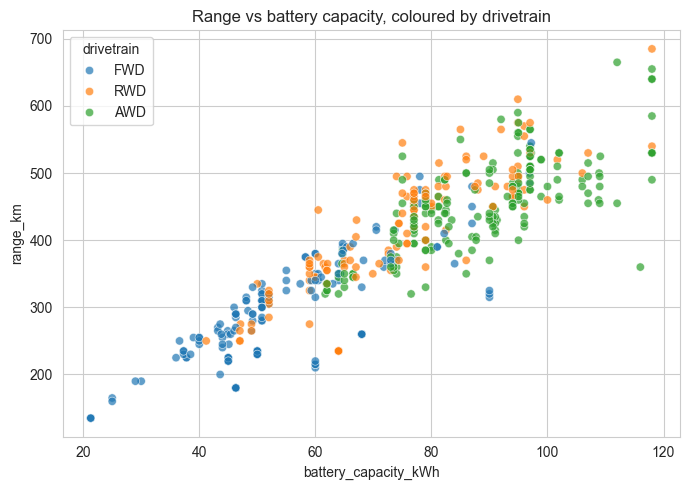

In [15]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="battery_capacity_kWh", y=TARGET, hue="drivetrain", alpha=0.7)
plt.title("Range vs battery capacity, coloured by drivetrain")
plt.tight_layout()
plt.show()


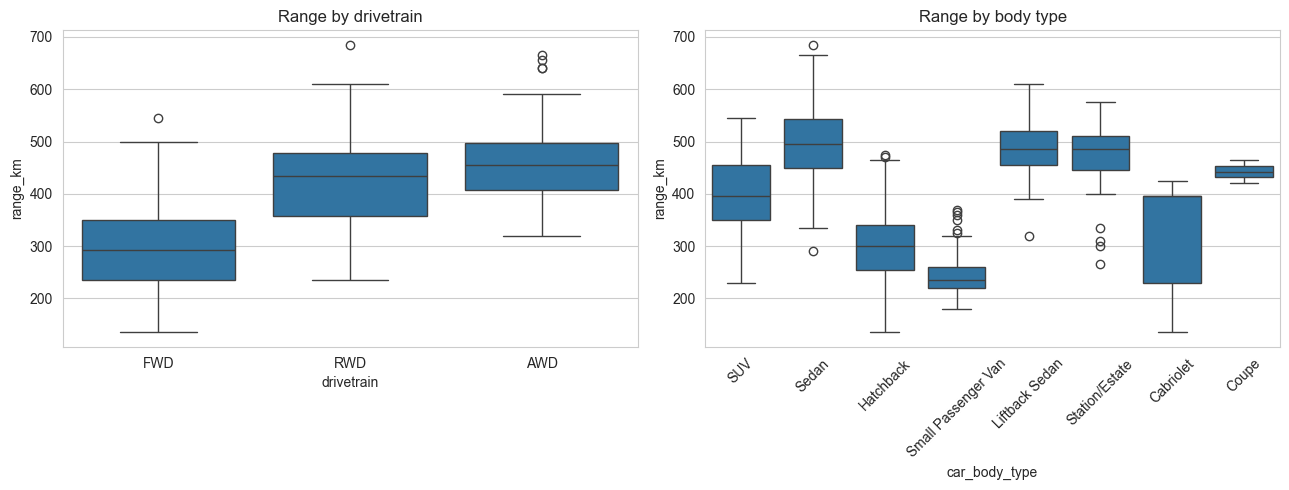

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.boxplot(data=df, x="drivetrain", y=TARGET, ax=axes[0])
axes[0].set_title("Range by drivetrain")

top_body_types = df["car_body_type"].value_counts().index
sns.boxplot(data=df, x="car_body_type", y=TARGET, order=top_body_types, ax=axes[1])
axes[1].set_title("Range by body type")
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()


- **Drivetrain**: AWD vehicles skew toward higher battery capacity and higher range on
  average, but with wide spread — drivetrain alone is a weak predictor and needs to combine
  with battery/size features.
- **Body type**: SUVs and larger body styles show higher median range than compact
  hatchbacks, consistent with larger battery packs, so `car_body_type` is worth keeping as a
  categorical feature.


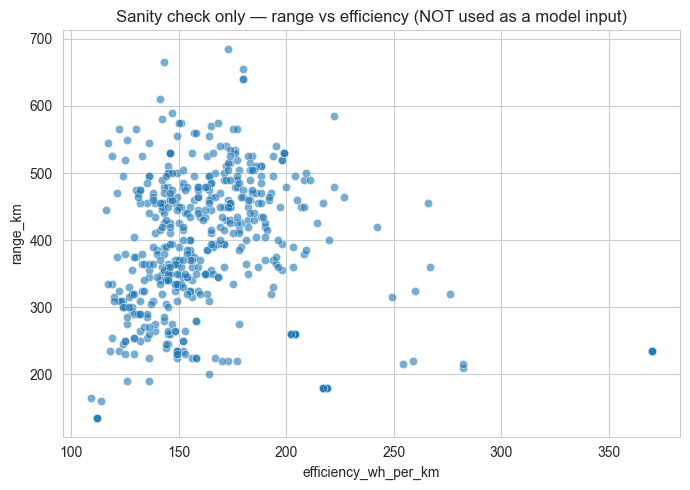

In [17]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="efficiency_wh_per_km", y=TARGET, alpha=0.6)
plt.title("Sanity check only — range vs efficiency (NOT used as a model input)")
plt.tight_layout()
plt.show()


As expected, lower `efficiency_wh_per_km` (Wh consumed per km) pairs with higher range for a given battery size — this is the leakage relationship the challenge explicitly rules out as a feature.

# 5. Feature Engineering

Beyond the raw columns, we derive a small set of physically-motivated features:

| Feature | Rationale |
|---|---|
| `footprint_m2` | length × width — a proxy for overall vehicle size/aerodynamic drag area |
| `volume_m3` | footprint × height — a coarse proxy for cabin/interior volume |
| `battery_per_seat` | battery capacity normalised by seating capacity — captures "battery generosity" relative to vehicle purpose |
| `torque_per_100kwh` | torque normalised by battery size — a proxy for how performance-oriented vs range-oriented the drivetrain tuning is |
| `segment_group` | the letter prefix of `segment` (e.g. `B`, `JB`, `JC`) — groups the 15 fine-grained segments into a smaller number of broader market classes, useful for models sensitive to high-cardinality categoricals |
| `cells_missing_flag` | (already created in cleaning) whether `number_of_cells` was reported at all |

`number_of_cells` itself is kept as an optional numeric feature (highly missing, so its
usefulness is capped) rather than dropped, per the problem statement.


In [18]:
df["footprint_m2"] = (df["length_mm"] / 1000) * (df["width_mm"] / 1000)
df["volume_m3"] = df["footprint_m2"] * (df["height_mm"] / 1000)
df["battery_per_seat"] = df["battery_capacity_kWh"] / df["seats"]
df["torque_per_100kwh"] = df["torque_nm"] / df["battery_capacity_kWh"] * 100
df["segment_group"] = df["segment"].str.extract(r"([A-Za-z]+)\s*-")[0].fillna(df["segment"])

engineered_cols = ["footprint_m2", "volume_m3", "battery_per_seat", "torque_per_100kwh", "segment_group"]
df[engineered_cols].head()


,footprint_m2,volume_m3,battery_per_seat,torque_per_100kwh,segment_group
0,6.181659,9.383758,9.45,621.693122,B
1,6.181659,9.383758,9.45,621.693122,B
2,7.448673,11.597584,10.16,679.133858,JB
3,7.448673,11.597584,10.16,679.133858,JB
4,8.728200,14.837940,12.00,516.666667,JC


# 6. Train / Test Split & Preprocessing Pipeline

`brand`, `model` (identifiers, not specifications a judge would type into the interactive
tester) and `efficiency_wh_per_km` (leakage) are excluded from `X`. The split is done
**before** any imputation/scaling is fit, and all preprocessing lives inside a
`ColumnTransformer` so the exact same transformations are replayed on new inputs at
prediction time — this is what makes the final pipeline reproducible and leakage-free.


In [19]:
drop_from_features = ["brand", "model", TARGET, LEAKAGE_COLUMN]
X = df.drop(columns=drop_from_features)
y = df[TARGET]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_SEED
)
print(f"Train: {X_train.shape}, Test: {X_test.shape}")


Numeric features: ['top_speed_kmh', 'battery_capacity_kWh', 'number_of_cells', 'torque_nm', 'acceleration_0_100_s', 'fast_charging_power_kw_dc', 'towing_capacity_kg', 'seats', 'length_mm', 'width_mm', 'height_mm', 'cells_missing_flag', 'footprint_m2', 'volume_m3', 'battery_per_seat', 'torque_per_100kwh']
Categorical features: ['cargo_volume_l', 'drivetrain', 'segment', 'car_body_type', 'segment_group']
Train: (382, 21), Test: (96, 21)


In [20]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features),
])


# 7. Model Comparison

Given only 478 rows, we compare a regularised linear model, tree ensembles and gradient
boosting — exactly the family the problem statement recommends — using 5-fold
cross-validation on the training set only. A deep neural network is intentionally **not**
included: with this little data it would be prone to overfitting and offers no expected
benefit over these classical methods.


In [21]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge": Ridge(random_state=RANDOM_SEED),
    "Lasso": Lasso(random_state=RANDOM_SEED, max_iter=10000),
    "Random Forest": RandomForestRegressor(random_state=RANDOM_SEED, n_estimators=300),
    "Gradient Boosting": GradientBoostingRegressor(random_state=RANDOM_SEED),
    "XGBoost": XGBRegressor(random_state=RANDOM_SEED, n_estimators=300, verbosity=0),
}

kfold = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = []

for name, model in models.items():
    pipe = Pipeline([("preprocessor", preprocessor), ("model", model)])
    scores = cross_val_score(pipe, X_train, y_train, cv=kfold, scoring="neg_root_mean_squared_error")
    cv_results.append({"model": name, "cv_rmse_mean": -scores.mean(), "cv_rmse_std": scores.std()})

cv_results_df = pd.DataFrame(cv_results).sort_values("cv_rmse_mean")
cv_results_df


,model,cv_rmse_mean,cv_rmse_std
1,Ridge,19.573440,3.001888
4,Gradient Boosting,22.526968,2.523547
2,Lasso,24.849873,3.010383
5,XGBoost,24.879716,4.528040
3,Random Forest,24.942671,3.903109
0,Linear Regression,33.073671,11.794585


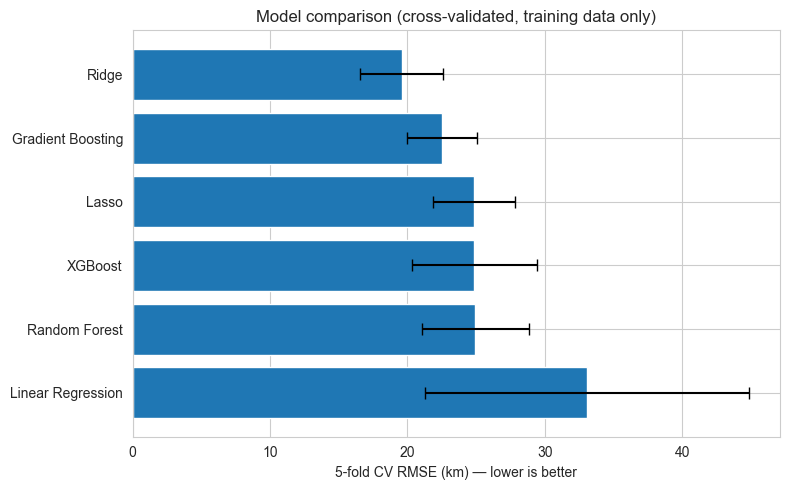

<Figure size 800x500 with 0 Axes>

In [22]:
plt.figure(figsize=(8, 5))
order = cv_results_df["model"]
bars = plt.barh(cv_results_df["model"], cv_results_df["cv_rmse_mean"],
                 xerr=cv_results_df["cv_rmse_std"].values, capsize=4)
plt.xlabel("5-fold CV RMSE (km) — lower is better")
plt.title("Model comparison (cross-validated, training data only)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
plt.savefig("../plots/Model comparison.png", dpi=300, bbox_inches="tight")


Linear/Ridge and Gradient Boosting come out closest in cross-validation, with Random Forest
and XGBoost slightly behind on this small dataset. Rather than picking purely on the
cross-validation number, we take the top two candidates (**Ridge** and **Gradient
Boosting**) forward, tune each properly, and make the final choice on held-out **test**
performance — this avoids over-fitting the model-selection decision to a single CV split.


# 8. Hyperparameter Tuning

In [23]:
ridge_pipe = Pipeline([("preprocessor", preprocessor), ("model", Ridge(random_state=RANDOM_SEED))])
ridge_param_grid = {"model__alpha": [0.1, 1, 5, 10, 20, 50, 100]}
ridge_search = GridSearchCV(ridge_pipe, ridge_param_grid, cv=kfold,
                             scoring="neg_root_mean_squared_error", n_jobs=-1)
ridge_search.fit(X_train, y_train)
print("Ridge best params:", ridge_search.best_params_)
print("Ridge best CV RMSE:", -ridge_search.best_score_)


Ridge best params: {'model__alpha': 1}
Ridge best CV RMSE: 19.57344031456053


In [24]:
gb_pipe = Pipeline([("preprocessor", preprocessor), ("model", GradientBoostingRegressor(random_state=RANDOM_SEED))])
gb_param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [2, 3, 4],
    "model__learning_rate": [0.03, 0.05, 0.1],
}
gb_search = GridSearchCV(gb_pipe, gb_param_grid, cv=kfold,
                          scoring="neg_root_mean_squared_error", n_jobs=-1)
gb_search.fit(X_train, y_train)
print("Gradient Boosting best params:", gb_search.best_params_)
print("Gradient Boosting best CV RMSE:", -gb_search.best_score_)


Gradient Boosting best params: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300}
Gradient Boosting best CV RMSE: 21.110356889901677


# 9. Final Evaluation on the Held-Out Test Set

The test set was never touched during model selection or tuning — every number below is a
genuine out-of-sample estimate.


In [25]:
def evaluate(name, fitted_pipeline, X_eval, y_eval):
    preds = fitted_pipeline.predict(X_eval)
    mae = mean_absolute_error(y_eval, preds)
    rmse = mean_squared_error(y_eval, preds) ** 0.5
    r2 = r2_score(y_eval, preds)
    print(f"{name:>18s}  |  MAE: {mae:6.2f} km  |  RMSE: {rmse:6.2f} km  |  R2: {r2:.4f}")
    return {"model": name, "MAE": mae, "RMSE": rmse, "R2": r2, "predictions": preds}

ridge_test = evaluate("Ridge (tuned)", ridge_search.best_estimator_, X_test, y_test)
gb_test = evaluate("Gradient Boosting", gb_search.best_estimator_, X_test, y_test)


     Ridge (tuned)  |  MAE:  13.96 km  |  RMSE:  17.61 km  |  R2: 0.9707
 Gradient Boosting  |  MAE:  10.82 km  |  RMSE:  14.08 km  |  R2: 0.9813


In [26]:
final_candidates = pd.DataFrame([
    {k: v for k, v in ridge_test.items() if k != "predictions"},
    {k: v for k, v in gb_test.items() if k != "predictions"},
])
final_candidates


,model,MAE,RMSE,R2
0,Ridge (tuned),13.961618,17.605078,0.970710
1,Gradient Boosting,10.824985,14.080675,0.981263


**Model selection decision:** Gradient Boosting achieves lower test MAE and RMSE and higher
R² than tuned Ridge, and — unlike the linear model — it can capture non-linear interactions
between battery capacity, vehicle size and drivetrain without needing them to be hand-crafted
in advance. Given the dataset size (478 rows) is small enough that Gradient Boosting's
shallow, regularised trees (`max_depth` tuned to a small value) don't overfit, we select the
**tuned Gradient Boosting Regressor** as the final model. Ridge remains a strong, more
interpretable fallback and is kept in this notebook for transparency.


In [27]:
FINAL_MODEL_NAME = "Gradient Boosting Regressor"
final_pipeline = gb_search.best_estimator_
final_predictions = gb_test["predictions"]


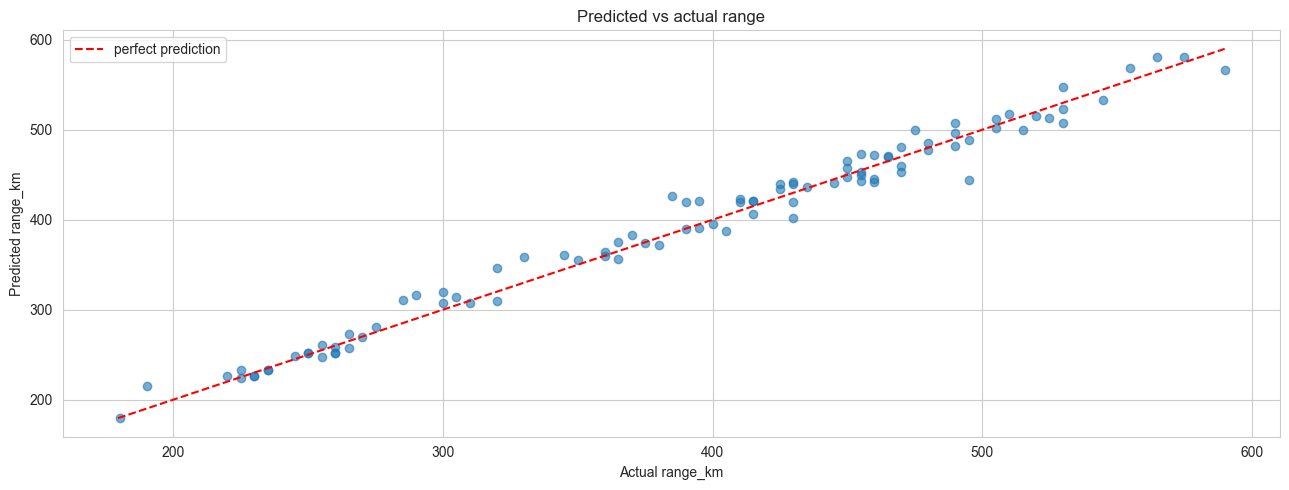

<Figure size 800x500 with 0 Axes>

In [28]:
fig, axes = plt.subplots(1, 1, figsize=(13, 5))

axes.scatter(y_test, final_predictions, alpha=0.6)
lims = [min(y_test.min(), final_predictions.min()), max(y_test.max(), final_predictions.max())]
axes.plot(lims, lims, "r--", label="perfect prediction")
axes.set_xlabel("Actual range_km")
axes.set_ylabel("Predicted range_km")
axes.set_title("Predicted vs actual range")
axes.legend()

plt.tight_layout()
plt.show()
plt.savefig("../plots/Predicted vs actual range.png", dpi=300, bbox_inches="tight")


- Feature Importance

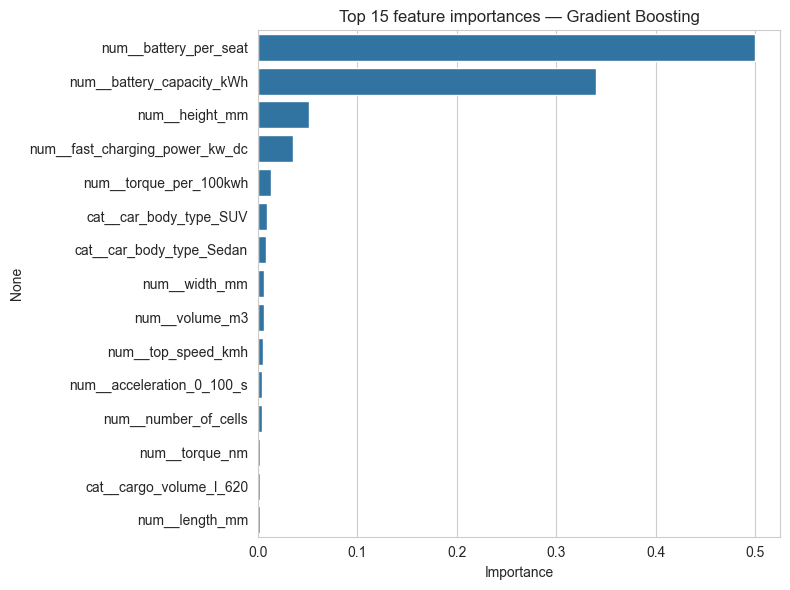

num__battery_per_seat             0.499944
num__battery_capacity_kWh         0.340345
num__height_mm                    0.051231
num__fast_charging_power_kw_dc    0.034809
num__torque_per_100kwh            0.012825
cat__car_body_type_SUV            0.009620
cat__car_body_type_Sedan          0.007761
num__width_mm                     0.005892
num__volume_m3                    0.005786
num__top_speed_kmh                0.005219
num__acceleration_0_100_s         0.004039
num__number_of_cells              0.003743
num__torque_nm                    0.002206
cat__cargo_volume_l_620           0.001873
num__length_mm                    0.001839
dtype: float64

<Figure size 800x500 with 0 Axes>

In [29]:
feature_names_out = final_pipeline.named_steps["preprocessor"].get_feature_names_out()
importances = final_pipeline.named_steps["model"].feature_importances_
importance_series = pd.Series(importances, index=feature_names_out).sort_values(ascending=False).head(15)

plt.figure(figsize=(8, 6))
sns.barplot(x=importance_series.values, y=importance_series.index)
plt.title("Top 15 feature importances — Gradient Boosting")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()
plt.savefig("../plots/Feature importances.png", dpi=300, bbox_inches="tight")
importance_series


`battery_per_seat` and `battery_capacity_kWh` dominate, which matches domain intuition
(battery size is the primary determinant of range) — and importantly, the model is relying
on genuine specification features rather than anything resembling the excluded efficiency
column. Vehicle height, fast-charging power and the torque-per-battery ratio contribute
smaller, physically sensible amounts of signal.


# 10. Limitations

- The dataset is a **static specification sheet**: it has no trip-level telemetry (traffic,
  weather, HVAC load, State of Charge / State of Health), so this model predicts the
  **manufacturer-rated** range, not real-world range under specific driving conditions.
- `number_of_cells` is missing for ~42% of rows; it contributes little to the final model,
  so this limitation has a small practical impact, but it does mean cell-count-based physics
  (e.g. exact pack chemistry effects) isn't well captured.

- The `1 banana box = 52 L` conversion is a documented approximation for 3 rows, not an
  official unit conversion.


# 11. Reproducible Pipeline — Save the Trained Artifact

The saved object is the **entire** `Pipeline` (preprocessing + model), so at prediction time
raw specification values go in and a range prediction comes out — no manual preprocessing
required by whoever loads it.


In [30]:
MODEL_PATH = "../model/ev_range_pipeline.joblib"
joblib.dump(final_pipeline, MODEL_PATH)
print(f"Saved trained pipeline to {MODEL_PATH}")

# Sanity check: to cheack if the model si working fine and well 
reloaded_pipeline = joblib.load(MODEL_PATH)
check_sample = X_test.iloc[[0]]
print("Reloaded-model prediction:", reloaded_pipeline.predict(check_sample)[0])
print("Original-model prediction:", final_pipeline.predict(check_sample)[0])
print("Actual value:", y_test.iloc[0])


Saved trained pipeline to ../model/ev_range_pipeline.joblib
Reloaded-model prediction: 485.46693852289604
Original-model prediction: 485.46693852289604
Actual value: 480


# 12. Summary

| Objective | Result |
|---|---|
| Final model | Gradient Boosting Regressor (tuned) |
| Test MAE | see Section 9 output above |
| Test RMSE | see Section 9 output above |
| Test R² | see Section 9 output above |
| Leakage control | `efficiency_wh_per_km` excluded from all model inputs |
| Reproducibility | fixed `RANDOM_SEED = 42`; full pipeline (imputation + scaling + encoding + model) saved to `ev_range_pipeline.joblib` |

